## Loading the Data

In [1]:
import zipfile
import os

# List of files to unzip
zip_files = [
    'images_training_rev1.zip', 
    'images_test_rev1.zip', 
    'training_solutions_rev1.zip'
]

base_input_path = '/kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge'
base_extract_path = '/kaggle/working/'

for file in zip_files:
    zip_path = os.path.join(base_input_path, file)
    
    # Create a specific folder for images, but keep the CSV in the main working dir
    if 'images' in file:
        folder_name = file.replace('.zip', '')
        extract_path = os.path.join(base_extract_path, folder_name)
    else:
        extract_path = base_extract_path
        
    os.makedirs(extract_path, exist_ok=True)

    print(f"Unzipping {file}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("All files extracted successfully.")

    location_path = os.path.join(base_extract_path, folder_name, folder_name)
    if os.path.exists(location_path):
        files = os.listdir(location_path)
        print(f"✅ Folder found!")
        print(f"Total files in training folder: {len(files)}")
        if len(files) > 0:
            print(f"Sample filename: {files[0]}")
    else:
        print("❌ Folder not found. Check your extraction path.")

Unzipping images_training_rev1.zip...
All files extracted successfully.
✅ Folder found!
Total files in training folder: 61578
Sample filename: 986739.jpg
Unzipping images_test_rev1.zip...
All files extracted successfully.
✅ Folder found!
Total files in training folder: 79975
Sample filename: 463202.jpg
Unzipping training_solutions_rev1.zip...
All files extracted successfully.
✅ Folder found!
Total files in training folder: 79975
Sample filename: 463202.jpg


## The Training CSV File

In [2]:
import pandas as pd

training_sol = pd.read_csv('/kaggle/working/training_solutions_rev1.csv')

print(training_sol.head(5))

   GalaxyID  Class1.1  Class1.2  Class1.3  Class2.1  Class2.2  Class3.1  \
0    100008  0.383147  0.616853  0.000000  0.000000  0.616853  0.038452   
1    100023  0.327001  0.663777  0.009222  0.031178  0.632599  0.467370   
2    100053  0.765717  0.177352  0.056931  0.000000  0.177352  0.000000   
3    100078  0.693377  0.238564  0.068059  0.000000  0.238564  0.109493   
4    100090  0.933839  0.000000  0.066161  0.000000  0.000000  0.000000   

   Class3.2  Class4.1  Class4.2  ...  Class9.3  Class10.1  Class10.2  \
0  0.578401  0.418398  0.198455  ...  0.000000   0.279952   0.138445   
1  0.165229  0.591328  0.041271  ...  0.018764   0.000000   0.131378   
2  0.177352  0.000000  0.177352  ...  0.000000   0.000000   0.000000   
3  0.129071  0.189098  0.049466  ...  0.000000   0.094549   0.000000   
4  0.000000  0.000000  0.000000  ...  0.000000   0.000000   0.000000   

   Class10.3  Class11.1  Class11.2  Class11.3  Class11.4  Class11.5  Class11.6  
0   0.000000   0.000000   0.092886 

Must translate the decision tree votes/responses into labels.

-> use Willett et al. (2013) -> wrote some notes on the math.

-> Can either use "Hierarchical Thresholding" (math discussed on Gemini, refer to notes) or The "Pseudo-Distribution" Approach (K-L Divergence) -> not as good for grad-cam, want hard boundaries

In [3]:
#Hierarchical Thresholding

def thresh_labels(row, thresh):
    #the standards for the thresholds are 0.8 (from Willett et al. (2013), 0.5, and 0.7 (for the further tasks))
    # Scaled in this definition since lower quality images can be insightful testing data
    # Rule 1: High Consensus Smooth = Elliptical
    if row['Class1.1'] >= thresh:
        return 'Elliptical'
    
    # Rule 2: High Consensus Features + Arms = Spiral
    # (Note: We ignore the small % of 'Smooth' votes here)
    if row['Class1.2'] >= thresh and row['Class4.1'] >= ((5/8)*thresh):
        return 'Spiral'
    
    # Rule 3: High Consensus Artifact or 'Odd' = Irregular
    if row['Class1.3'] >= thresh or row['Class6.1'] >= ((7/8)*thresh):
        return 'Irregular'
    
    # Rule 4: If no consensus, throw it out! (Prevents noisy training)
    return 'Uncertain'

In [4]:
target_thresh = 0.8

# 3. Apply the function to create a new column
# 'args' passes the thresh value to your function
training_sol['label'] = training_sol.apply(thresh_labels, axis=1, thresh=target_thresh)

# 4. Filter out the 'Uncertain' rows to get your final labeled DF
trai_sol_labeled = training_sol[training_sol['label'] != 'Uncertain'].copy()

# 5. Check the results
print(f"Original size: {len(training_sol)}")
print(f"Labeled size: {len(trai_sol_labeled)}")
print(trai_sol_labeled['label'].value_counts())

Original size: 61578
Labeled size: 20529
label
Spiral        9107
Elliptical    8132
Irregular     3290
Name: count, dtype: int64


-> should consider data augmentation, esp for irregular

## EDA of the Images

### Visualizing Class Prototypes

In [5]:
import matplotlib.pyplot as plt
import cv2
import os

def plot_class_samples(df, label, img_path, n=5):
    # Get top 5 most confident samples for that label
    samples = df[df['label'] == label].sample(n) 
    
    plt.figure(figsize=(15, 5))
    for i, (idx, row) in enumerate(samples.iterrows()):
        img = cv2.imread(os.path.join(img_path, f"{int(row['GalaxyID'])}.jpg"))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"{label}\nID: {int(row['GalaxyID'])}")
        plt.axis('off')
    plt.show()

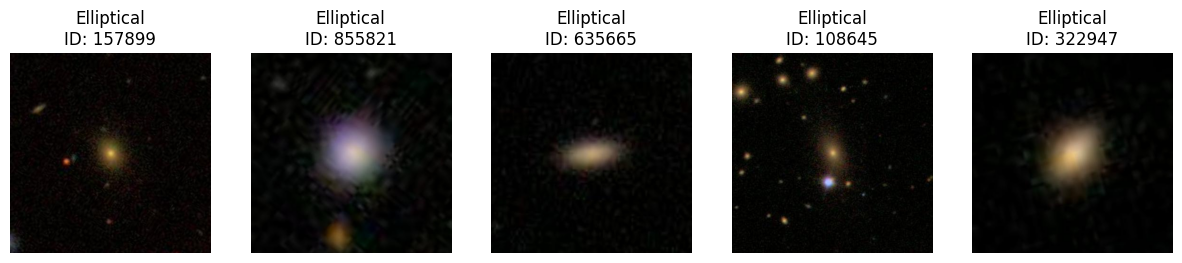

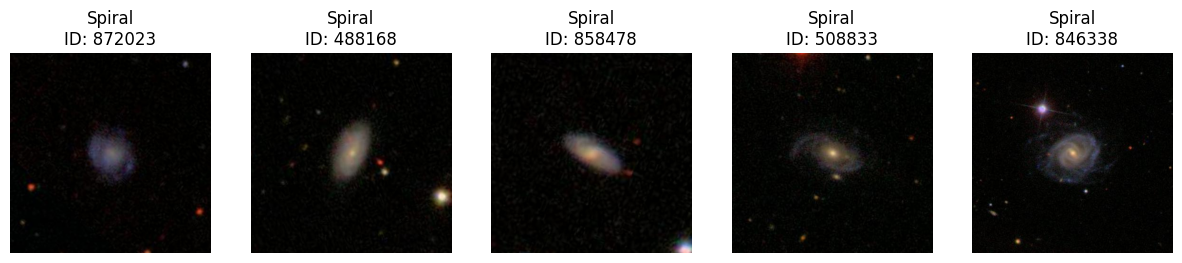

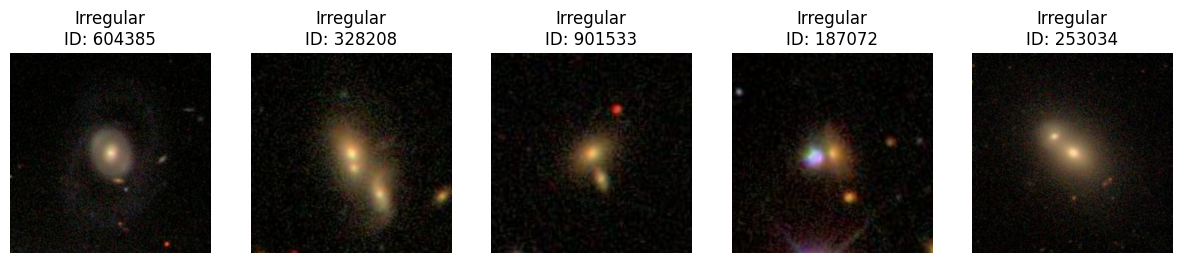

In [6]:
# Run for each class
for cls in ['Elliptical', 'Spiral', 'Irregular']:
    plot_class_samples(trai_sol_labeled, cls, '/kaggle/working/images_training_rev1/images_training_rev1')